# Finance, Revisited 
## 2026

# Contents 

# I. - PLBGR 
## A. - CORRELATION CALCULATIONS
### 1. - DIRECT
### 2. - RELATIVE 
## B. - INTERASIGNAL DEVIATIONS

# II. - GSPCC
## A. - CORRELATION CALCULATIONS
### 1. - DIRECT
### 2. - RELATIVE 
## B. - INTERASIGNAL DEVIATIONS

In [1]:
# pip install numpy pandas matplotlib yfinance
#
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import yfinance as yf

/Users/andrewbonham/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# I. PLBGR

## A. - CORRELATION CALCULATIONS

### 1. - DIRECT

In [2]:
symbols = ["GUER", "PLAB"]

DATA = yf.download(symbols, start="2025-08-01")["Close"]
DN = DATA / DATA.iloc[0]

window = 23
spread = 11
t = 60

X, Y = DN.iloc[t : t + window, 0], DN.iloc[t + spread : t + window + spread, 1]
COEF = float(np.corrcoef(X, Y)[1][0])
delta = (
    (np.array(X.pct_change().dropna()) ** 2 + np.array(Y.pct_change().dropna()) ** 2)
    ** 0.5
).mean()  # ad hoc uncertainty intrasignal
print(f"\nCOEF: {100 * COEF:.1f}% +/- {100 * delta:.1f}%")  # better options available

[*********************100%***********************]  2 of 2 completed


COEF: 96.3% +/- 10.5%


In [3]:
_x, _y = np.array(X / X.iloc[0]), np.array(Y / Y.iloc[0])
_x = (_x - 1) * (_y[-1] - 1) / (_x[-1] - 1) + 1
e = np.mean((_x - _y) ** 2) ** 0.5
idxs = [
    f"{DN.index[t]}\n{DN.index[t + spread]}".replace(" 00:00:00", ""),
    f"{DN.index[t + window]}\n{DN.index[t + window + spread]}".replace(" 00:00:00", ""),
]

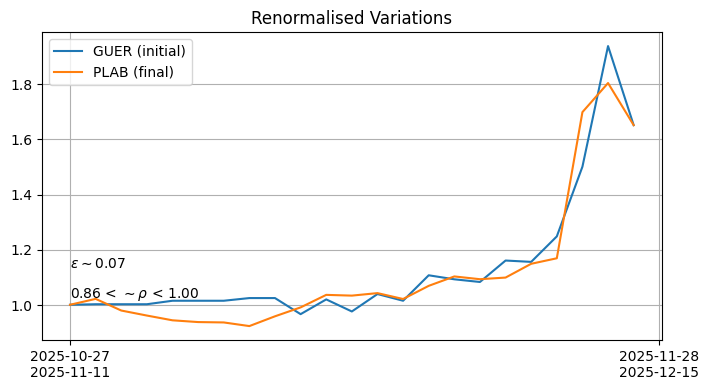


COEF: 96.3% +/ 10.5%
Internalised rates of return: ~584566% (GUER) and ~29909% (PLAB).


In [4]:
plt.figure(figsize=(8, 4))
plt.title("Renormalised Variations")
plt.plot(_x, label="GUER (initial)")
plt.plot(_y, label="PLAB (final)")
plt.text(0, np.mean(_x), f"$\\varepsilon \sim {e:.2f}$")
plt.text(
    0,
    np.median(_x),
    f"{(COEF - delta):.2f} < $\sim\\rho$ < {(min(1, COEF + delta)):.2f}",
)  # better options available
plt.xticks([0, len(_x)], idxs)
plt.legend()
plt.grid()
plt.show()

irrx, irry = (X.iloc[-1] / X.iloc[0]) ** (250 / (X.shape[0] - 1)) - 1, (
    Y.iloc[-1] / Y.iloc[0]
) ** (250 / (Y.shape[0] - 1)) - 1

irrx, irry = float(irrx), float(irry)

# BASIC STATS
print(f"\nCOEF: {100 * COEF:.1f}% +/ {100 * delta:.1f}%")  # better options available

out_string = f"Internalised rates of return: ~{100*irrx:.0f}% (GUER) and ~{100 * irry:.0f}% (PLAB)."
print(out_string)

### 2. - RELATIVE

In [5]:
start = "2025-01-01"
end = None

symbols = ["GUER", "PLAB"]

DATA = yf.download(symbols, start=start, end=end)["Close"]

spread_months = np.linspace(0, 1, 11)
spread_days = spread_months * 250 / 12
spread_days = spread_days.astype(int)

coefs = []
dates = []

for i in range(DN.shape[0] - spread_days[-1] - window):
    x = DN.iloc[i : i + window, 0]
    for spread in spread_days:
        y = DN.iloc[i + spread : i + window + spread, 1]
        coef = np.cov(x, y) / (np.std(x) * np.std(y))
        coef = float(coef[1][0])
        coefs.append(coef)

coefs = np.array(coefs)

mean_, median_, std_ = (
    float(np.mean(coefs)),
    float(np.median(coefs)),
    float(np.std(coefs)),
)

[*********************100%***********************]  2 of 2 completed


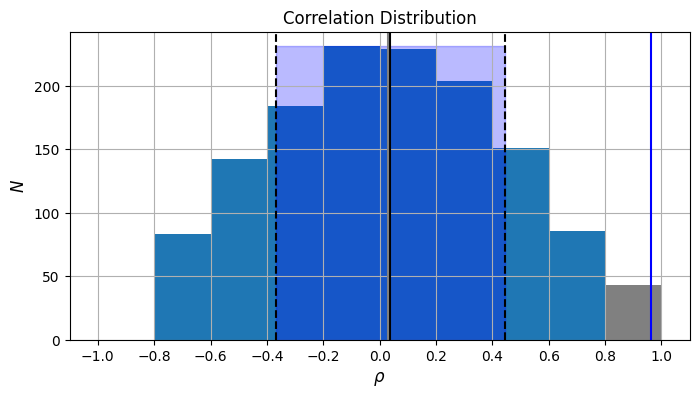

COEF 
Measured: 96.31% +/- 10.52%
Mean: 3.78%
Median: 2.80%
Standard deviation: 40.74%
Relative frequency (approximate): 3.18%
Relative frequency (precise): 0.15%


In [6]:
x_min, x_max = -1, 1
n_bins = 11
bins = np.linspace(x_min, x_max, n_bins)
c_upper, c_lower = mean_ + std_, mean_ - std_
# can use geometric or arithmetic mean of mean_ and median_ # do not post the real version of this file.
plt.figure(figsize=(8, 4))
x, y, z = plt.hist(coefs, bins=bins)
plt.title("Correlation Distribution", fontsize=12)
plt.ylabel("$N$", fontsize=12)
plt.xlabel("$\\rho$", fontsize=12)
plt.xticks(bins)
plt.grid()
plt.axvline(COEF, color="blue")
plt.fill_betweenx((0, np.max(x)), c_lower, c_upper, color="blue", alpha=0.27)
plt.axvline(c_upper, color="k", linestyle="--")
plt.axvline(mean_, color="k")
plt.axvline(median_, color="gray")
plt.axvline(c_lower, color="k", linestyle="--")
z[-1].set_facecolor("gray")
plt.show()
# STATS
print(
    f"COEF \nMeasured: {100 * COEF:.2f}% +/- {100 * delta:.2f}%\nMean: {100 * mean_:.2f}%\nMedian: {100 * median_:.2f}%\nStandard deviation: {100 * std_:.2f}%"
)
print(f"Relative frequency (approximate): {100 * x[-1] / len(coefs):.2f}%")
print(
    f"Relative frequency (precise): {100 * (1 - (COEF > coefs).sum() / len(coefs)):.2f}%"
)

## B. - INTERASIGNAL DEVIATIONS

In [7]:
X, Y = np.array(X), np.array(Y)

DX = np.abs(X[1:] / X[:-1])
DY = np.abs(Y[1:] / Y[:-1])
D2 = DX**2 + DY**2
# D2 = DX * DY
D = D2**0.5
D_ = np.array([D, D2])
DM, DD = D_.mean(axis=1), np.median(D_, axis=1)

E = np.abs(X[1:] / Y[1:])
E2 = E**2
E_ = np.array([E, E2])
EM, ED = E_.mean(axis=1), np.median(E_, axis=1)

C = E / D - 1
CM, CD = np.mean(C), np.median(C)
C_ = np.array([CM, CD])
C_A = np.mean(C_)
C_G = np.prod(1 + C_) ** (1 / len(C_)) - 1
S = np.std(C)


C2 = E2 / D2 - 1
C2M, C2D = np.mean(C2), np.median(C2)
C2_ = np.array([C2M, C2D])
C2_A = np.mean(C2_)
C2_G = np.prod(1 + C2_) ** (1 / len(C2_)) - 1
S_2 = np.std(C2)

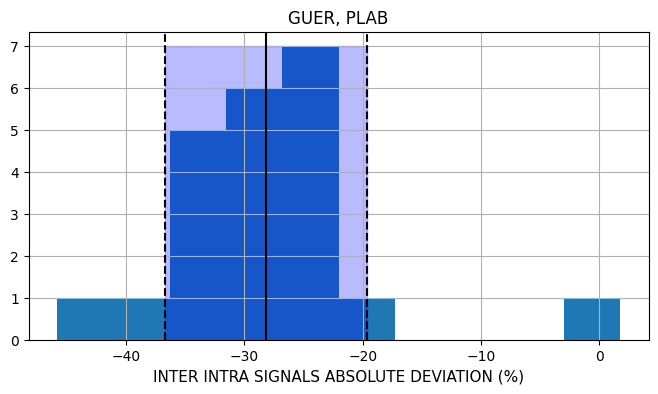

GUER, PLAB
absolute per cent cut:
-28.2% mean (M) and -28.4% median (D);
-28.3% MDA (MD-Arithmetic) and -28.3% MDG (MD-Geometric);
8.5% standard eviation;

quadratic per cent cut:
-47.7% mean (M) and -48.7% median (D);
-48.2% MDA (MD-Arithmetic) and -48.2% MDG (MD-Geometric);
13.4% standard eviation;




In [8]:
bins = 10
plt.figure(figsize=(8, 4))
plt.title(", ".join(symbols), fontsize=12)
x, y, z = plt.hist(100 * C, bins=bins)
c_lower = 100 * (CM - S)
c_upper = 100 * (CM + S)
plt.fill_betweenx((0, np.max(x)), c_lower, c_upper, color="blue", alpha=0.27)
plt.axvline(c_lower, linestyle="--", color="black")
plt.axvline(c_upper, linestyle="--", color="black")
plt.axvline(100 * CM, color="black")
plt.xlabel("INTER INTRA SIGNALS ABSOLUTE DEVIATION (%)", fontsize=11)
plt.grid()
plt.show()

# ABSOLUTE INTERASIGNAL DEVIATIONS STATS
out_string = f"{', '.join(symbols)}\n"
out_string += f"absolute per cent cut:\n"
out_string += f"{100 * CM:.1f}% mean (M) and {100 * CD:.1f}% median (D);\n"
out_string += f"{100 * C_A:.1f}% MDA (MD-Arithmetic) "
out_string += f"and {100 * C_G:.1f}% MDG (MD-Geometric);\n"
out_string += f"{100 * S:.1f}% standard eviation;\n\n"
# QUADRATIC
out_string += f"quadratic per cent cut:\n"
out_string += f"{100 * C2M:.1f}% mean (M) and {100 * C2D:.1f}% median (D);\n"
out_string += f"{100 * C2_A:.1f}% MDA (MD-Arithmetic) "
out_string += f"and {100 * C2_G:.1f}% MDG (MD-Geometric);\n"
out_string += f"{100 * S_2:.1f}% standard eviation;\n\n"
print(out_string)

# II. - GSPCC

## A. - CORRELATION CALCULATIONS

### 1. - DIRECT

In [9]:
# PRELIMINARIES

N = 40

symbols = [
    "BA",
    "INTC",
    "LPLA",
    "MU",
]

start = "2024-06-28"
end = "2024-10-01"

S = yf.download(symbols, start=start, end=end)["Close"]
DATA = S / S.iloc[0]

MEAN_N = DATA.mean(axis=1)
X = MEAN_N.iloc[: N + 1]

# # IRR = (MEAN_N.loc["2024-08-07"] / MEAN_N.loc["2024-07-01"]) ** (251 / (MEAN_N.index.get_loc("2024-08-07") - MEAN_N.index.get_loc("2024-07-01"))) - 1
IRR = (MEAN_N.loc["2024-08-07"] / MEAN_N.loc["2024-07-10"]) ** (
    251 / (MEAN_N.index.get_loc("2024-08-07") - MEAN_N.index.get_loc("2024-07-10"))
) - 1
IRR = float(IRR)

[*********************100%***********************]  4 of 4 completed


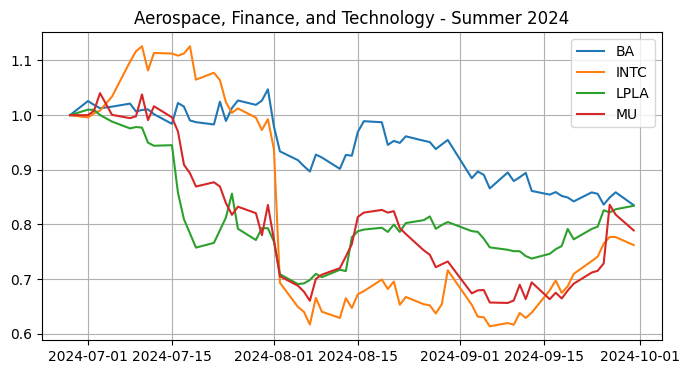

Mean of ['BA', 'INTC', 'LPLA', 'MU'] peak decline
Internalised rate of return: -99.0% (approx.)


In [10]:
# CONSTRICTED INDEX

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(DATA, label=DATA.columns)
plt.title("Aerospace, Finance, and Technology - Summer 2024", fontsize=12)
plt.grid()
plt.legend()
plt.show()

# INTERNALISED RATE OF RETURN
print(
    f"Mean of {symbols} peak decline\nInternalised rate of return: {100*IRR:.1f}% (approx.)"
)

#### GSPC - Spring, 2025.

In [11]:
idx = "^GSPC"
start = "2025-02-01"
end = "2025-05-01"
IDX = yf.download(idx, start=start, end=end)["Close"]
IDX_N = IDX / IDX.iloc[0]
Y = IDX_N["^GSPC"].iloc[: N + 1]

x_, y_ = np.array(X), np.array(Y)
x_ = (x_ - 1) * (y_[-1] - 1) / (x_[-1] - 1) + 1

e = np.mean((y_ - x_) ** 2) ** 0.5

[*********************100%***********************]  1 of 1 completed


/var/folders/wx/yl1wgtq52sgd7gpfg2qt7d5w0000gn/T/ipykernel_4348/3518499765.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


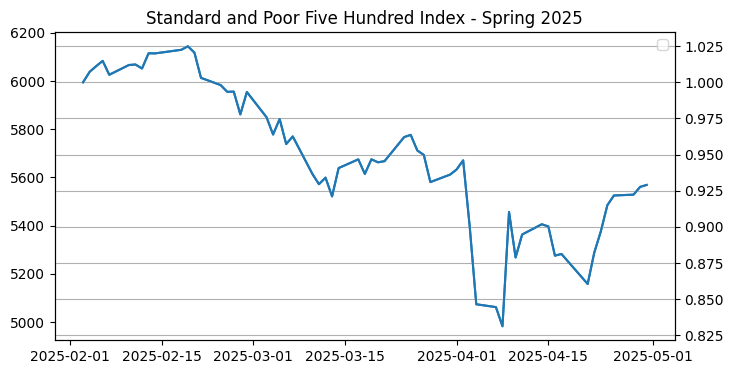

^GSPC peak decline Internalised rate of return: -77.1% (approx.)


In [12]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(IDX, label=idx)
ax2 = ax1.twinx()
ax2.plot(IDX_N)
plt.title("Standard and Poor Five Hundred Index - Spring 2025", fontsize=12)
plt.legend()
plt.grid()
plt.show()

# INTERNALISED RATE OF RETURN
IRR = (IDX.loc["2025-04-07"] / IDX.loc["2025-02-19"]) ** (
    251 / (IDX.index.get_loc("2025-04-07") - IDX.index.get_loc("2025-02-19"))
) - 1
IRR = float(IRR.iloc[0])
print(f"{idx} peak decline Internalised rate of return: {100*IRR:.1f}% (approx.)")

In [13]:
COEF = np.corrcoef(x_, y_)[1][0]
delta = (
    (np.array(X.pct_change().dropna()) ** 2 + np.array(Y.pct_change().dropna()) ** 2)
    ** 0.5
).mean()  # ad hoc uncertainty intrasignal
print(f"\nCOEF: {100 * COEF:.1f}% +/- {100 * delta:.1f}%")  # better options available


COEF: 95.3% +/- 2.2%


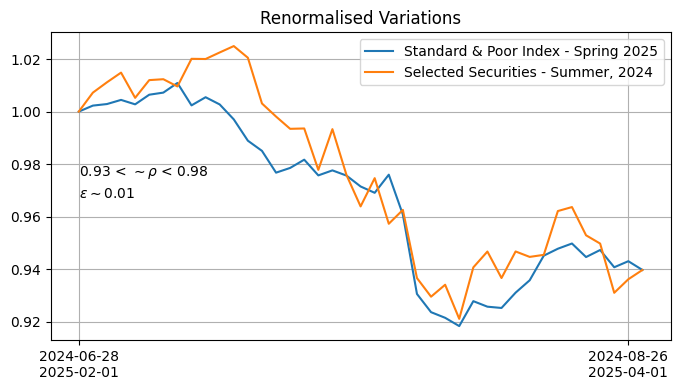


COEF: 95.3% +/- 2.2% (approx.)


In [14]:
plt.figure(figsize=(8, 4))
plt.plot(x_, label="Standard & Poor Index - Spring 2025")
plt.plot(y_, label="Selected Securities - Summer, 2024")
plt.grid()
plt.title("Renormalised Variations", fontsize=12)
plt.text(
    0,
    np.median(x_),
    f"{(COEF - delta):.2f} < $\sim\\rho$ < {(min(1, COEF + delta)):.2f}",
)  # better options available
plt.text(0, np.mean(x_), f"$\epsilon \sim ${e:.2f}")
plt.xticks([0, N - 1], ["2024-06-28\n2025-02-01", "2024-08-26\n2025-04-01"])
plt.legend()
plt.show()
# BASIC
print(
    f"\nCOEF: {100 * COEF:.1f}% +/- {100 * delta:.1f}% (approx.)"
)  # betrer options available

### 2. - CALCULATIONS RELATIVE 

In [15]:
start = "2024-01-01"
end = None

symbols = ["BA", "INTC", "LPLA", "MU"]

DATA = yf.download(symbols, start=start, end=end)["Close"]

idx = "^GSPC"
IDX = yf.download(idx, start=start, end=end)["Close"]
IDX_N = IDX / IDX.iloc[0]

spread_months = np.linspace(5, 10, 101)
spread_days = spread_months * 250 / 12
spread_days = spread_days.astype(int)

window = N

coefs = []
dates = []

for i in range(IDX_N.shape[0] - spread_days[-1] - window):
    x = (DATA.iloc[i : i + window] / DATA.iloc[i]).mean(axis=1)
    for spread in spread_days:
        y = (
            IDX_N["^GSPC"].iloc[i + spread : i + spread + window]
            / IDX_N["^GSPC"].iloc[i + spread]
        )
        coef = np.corrcoef(x, y)
        coef = float(coef[1][0])
        coefs.append(coef)

coefs = np.array(coefs)

mean_, std_ = float(np.mean(coefs)), float(np.std(coefs))

print(f"COEF {COEF:.4f}\nMean: {mean_:.4f}\nStandard deviation: {std_:.4f}")

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


COEF 0.9532
Mean: 0.0837
Standard deviation: 0.4747


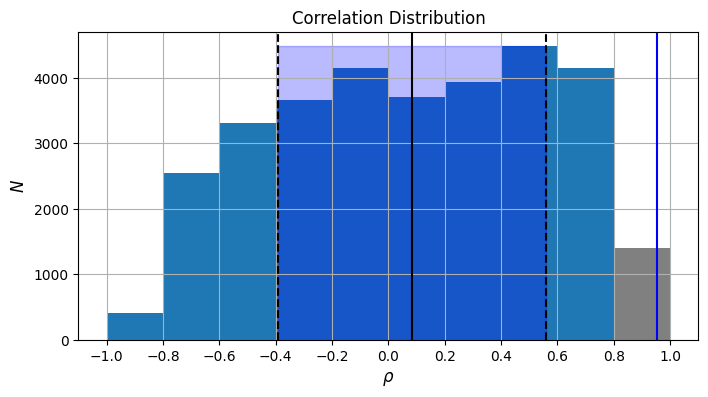

COEF 
Measured: 95.32% +/- 2.25%
Mean: 8.37%
Median: 2.80%
Standard deviation: 47.47%
Relative frequency (approximate): 4.41%
Relative frequency (precise): 0.02%


In [16]:
x_min, x_max = -1, 1
n_bins = 11
bins = np.linspace(x_min, x_max, n_bins)
c_upper, c_lower = mean_ + std_, mean_ - std_

plt.figure(figsize=(8, 4))
x, y, z = plt.hist(coefs, bins=bins)
plt.title("Correlation Distribution", fontsize=12)
plt.ylabel("$N$", fontsize=12)
plt.xlabel("$\\rho$", fontsize=12)
plt.xticks(bins)
plt.grid()
plt.axvline(COEF, color="blue")
plt.fill_betweenx((0, np.max(x)), c_lower, c_upper, color="blue", alpha=0.27)
plt.axvline(c_upper, color="k", linestyle="--")
plt.axvline(mean_, color="k")
plt.axvline(c_lower, color="k", linestyle="--")
z[-1].set_facecolor("gray")
plt.show()
# STATS
print(
    f"COEF \nMeasured: {100 * COEF:.2f}% +/- {100 * delta:.2f}%\nMean: {100 * mean_:.2f}%\nMedian: {100 * median_:.2f}%\nStandard deviation: {100 * std_:.2f}%"
)
print(f"Relative frequency (approximate): {100 * x[-1] / len(coefs):.2f}%")
print(
    f"Relative frequency (precise): {100 * (1 - (COEF > coefs).sum() / len(coefs)):.2f}%"
)

## B. - INTERASIGNAL DEVIATIONS

In [17]:
X, Y = np.array(X), np.array(Y)

DX = np.abs(X[1:] / X[:-1])
DY = np.abs(Y[1:] / Y[:-1])
D2 = DX**2 + DY**2
D = D2**0.5
D_ = np.array([D, D2])
DM, DD = D_.mean(axis=1), np.median(D_, axis=1)

E = np.abs(X[1:] / Y[1:])
E2 = E**2
E_ = np.array([E, E2])
EM, ED = E_.mean(axis=1), np.median(E_, axis=1)

C = E / D - 1
CM, CD = np.mean(C), np.median(C)
C_ = np.array([CM, CD])
C_A = np.mean(C_)
C_G = np.prod(1 + C_) ** (1 / len(C_)) - 1
S = np.std(C)


C2 = E2 / D2 - 1
C2M, C2D = np.mean(C2), np.median(C2)
C2_ = np.array([C2M, C2D])
C2_A = np.mean(C2_)
C2_G = np.prod(1 + C2_) ** (1 / len(C2_)) - 1
S_2 = np.std(C2)

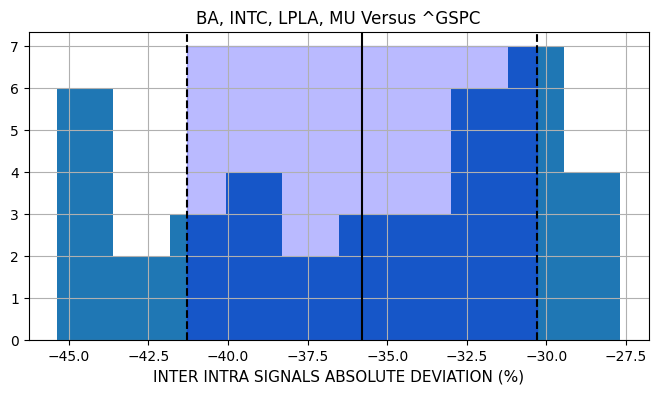

BA, INTC, LPLA, MU versus ^GSPC
absolute per cent cut:
-35.8% mean (M) and -34.5% median (D);
-35.1% MDA (MD-Arithmetic) and -35.1% MDG (MD-Geometric);
5.5% standard eviation;


BA, INTC, LPLA, MU versus ^GSPC
quadratic per cent cut:
-58.5% mean (M) and -57.1% median (D);
-57.8% MDA (MD-Arithmetic) and -57.8% MDG (MD-Geometric);
7.0% standard eviation.



In [18]:
bins = 10
plt.figure(figsize=(8, 4))
plt.title(f"{', '.join(symbols)} Versus {idx}", fontsize=12)
x, y, z = plt.hist(100 * C, bins=bins)
c_lower = 100 * (CM - S)
c_upper = 100 * (CM + S)
plt.fill_betweenx((0, np.max(x)), c_lower, c_upper, color="blue", alpha=0.27)
plt.axvline(c_lower, linestyle="--", color="black")
plt.axvline(c_upper, linestyle="--", color="black")
plt.axvline(100 * CM, color="black")
plt.xlabel("INTER INTRA SIGNALS ABSOLUTE DEVIATION (%)", fontsize=11)
plt.grid()
plt.show()

# Absolute percent cut
out_string = f"{', '.join(symbols)} versus {idx}\n"
out_string += f"absolute per cent cut:\n"
out_string += f"{100 * CM:.1f}% mean (M) and {100 * CD:.1f}% median (D);\n"
out_string += f"{100 * C_A:.1f}% MDA (MD-Arithmetic) "
out_string += f"and {100 * C_G:.1f}% MDG (MD-Geometric);\n"
out_string += f"{100 * S:.1f}% standard eviation;\n\n"
print(out_string)

# quadratic
out_string = f"{', '.join(symbols)} versus {idx}\n"
out_string += f"quadratic per cent cut:\n"
out_string += f"{100 * C2M:.1f}% mean (M) and {100 * C2D:.1f}% median (D);\n"
out_string += f"{100 * C2_A:.1f}% MDA (MD-Arithmetic) "
out_string += f"and {100 * C2_G:.1f}% MDG (MD-Geometric);\n"
out_string += f"{100 * S_2:.1f}% standard eviation.\n"
print(out_string)

# ---------

#### Finance, Revisited 
#### 2026

# ---------